In [1]:
import jax 
import jax.numpy as jnp

from probjax.inference.mcmc import MCMC
from probjax.inference.transition_kernels import HMCKernel, GaussianKernel, LangevinDynKernel, SliceKernel

import seaborn as sns
import pandas as pd
from functools import partial

from probjax.core import joint_sample, log_potential_fn, rv, intervene, JaxprGraph
from probjax.distributions import Normal 
from probjax.utils.jaxutils import flatten1d

In [2]:
def model(key):
    key1, key2, key3, key4 = jax.random.split(key, 4)
    theta1 = rv(Normal(0., 3.), name = "theta1")(key1)
    theta2 = rv(Normal(0., 3.), name = "theta2")(key2)
    z1 = jnp.sin(theta1)*2
    x1 = rv(Normal(z1, 0.5), name = "x1")(key3)
    z2 = theta2**2
    x2 = rv(Normal(0.05 * z2, 0.2 *jnp.exp(x1) + 0.1), name = "x2")(key4)
    x3 = rv(Normal(jnp.cos(x2), 0.1), name = "x3")(key4)
    
    
    

In [3]:
key = jax.random.PRNGKey(0)

joint_sampler = joint_sample(model)
potential_fn = log_potential_fn(joint_sampler)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [4]:
var_names = ["theta1", "theta2", "x1", "x2"]

In [5]:
@partial(jax.vmap, in_axes = [0, None, None])
def sample_fn(key, condition_mask, x_o):
    kernel = HMCKernel(step_size=0.01)
    init_vals = joint_sampler(key)
   
   
    conditioned_names = [var_names[i] for i in range(len(var_names)) if condition_mask[i]]
    conditioned_nodes = {var: val for var, val in zip(conditioned_names, x_o)}
        
    sampler = intervene(joint_sampler, conditioned_nodes)
    potential_fn = log_potential_fn(sampler)
    
    for var in conditioned_names:
        del init_vals[var]
    
    flattened_vals, in_tree = jax.tree_util.tree_flatten(init_vals)
    flat_init_vals = jnp.stack(flattened_vals)
    
    @jax.jit
    def potential_function(flattened_vals):
        vals = jax.tree_util.tree_unflatten(in_tree, flattened_vals)
        return potential_fn(**vals)
    
    mcmc = MCMC(kernel, potential_function, flat_init_vals)
    samples = mcmc.run(key, 5000)
    return samples

In [6]:
condition_mask = jnp.array([0, 0, 0,0, 0], dtype = bool)
samples = sample_fn(jax.random.split(key, (10000,)), condition_mask, jnp.array([0., 0.]))

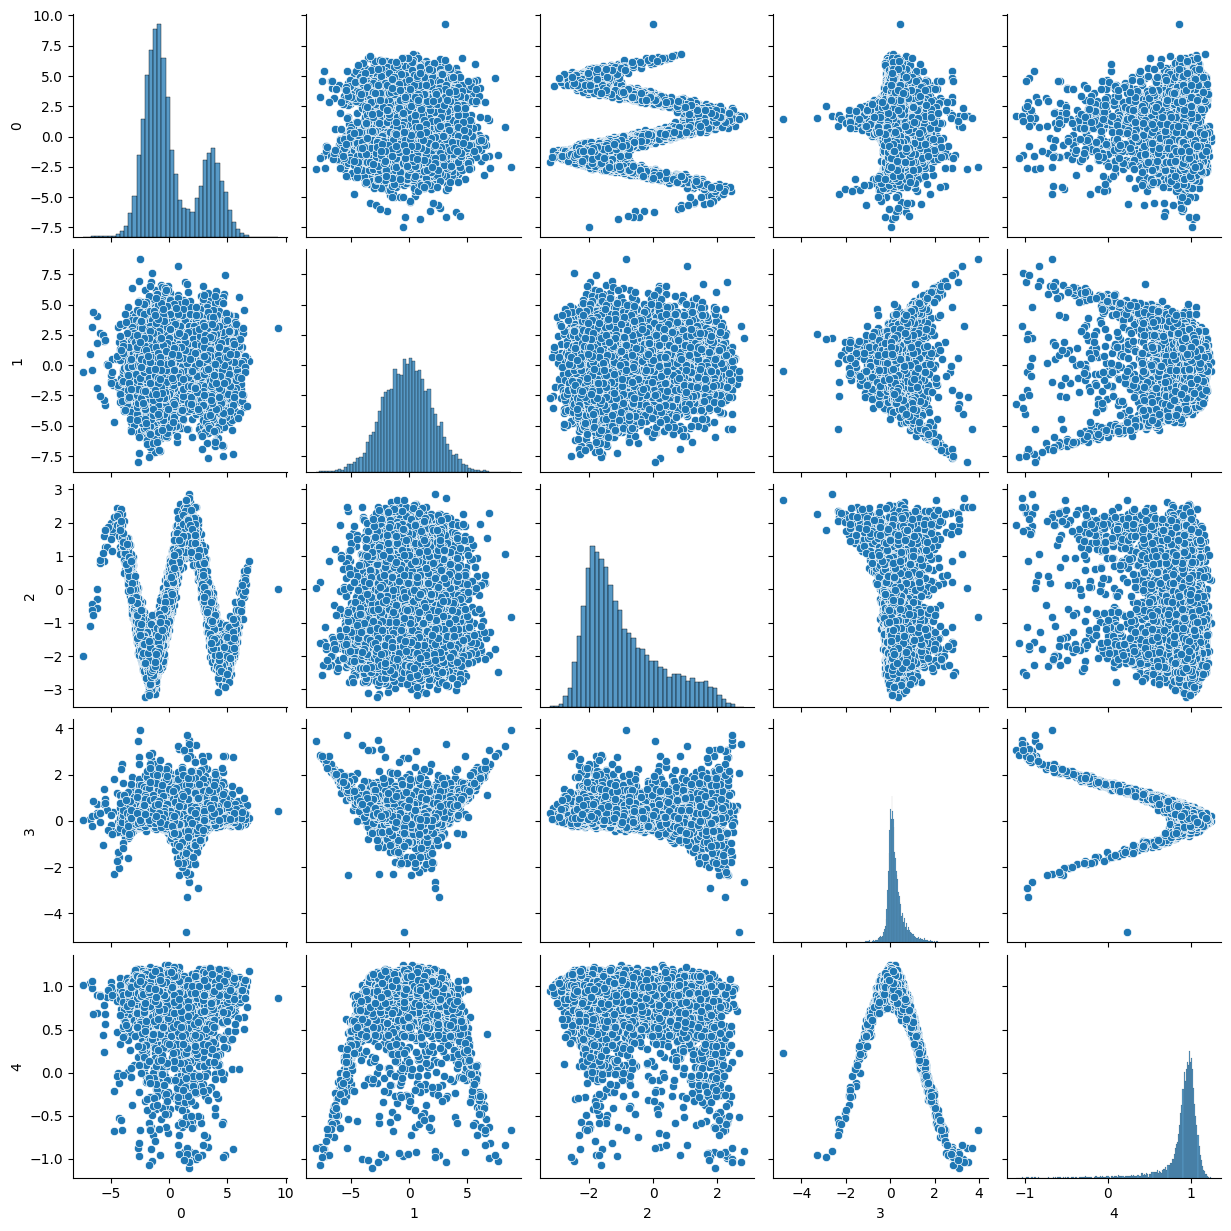

In [7]:
sns.pairplot(pd.DataFrame(samples))

In [6]:
from jax.flatten_util import ravel_pytree

In [7]:
samples = jax.vmap(joint_sampler)(jax.random.split(key, (10000,)))
samples = jnp.stack(jax.tree_flatten(samples)[0]).T

/tmp/ipykernel_3847/1415182472.py:2: DeprecationWarning: jax.tree_flatten is deprecated: use jax.tree_util.tree_flatten.
  samples = jnp.stack(jax.tree_flatten(samples)[0]).T


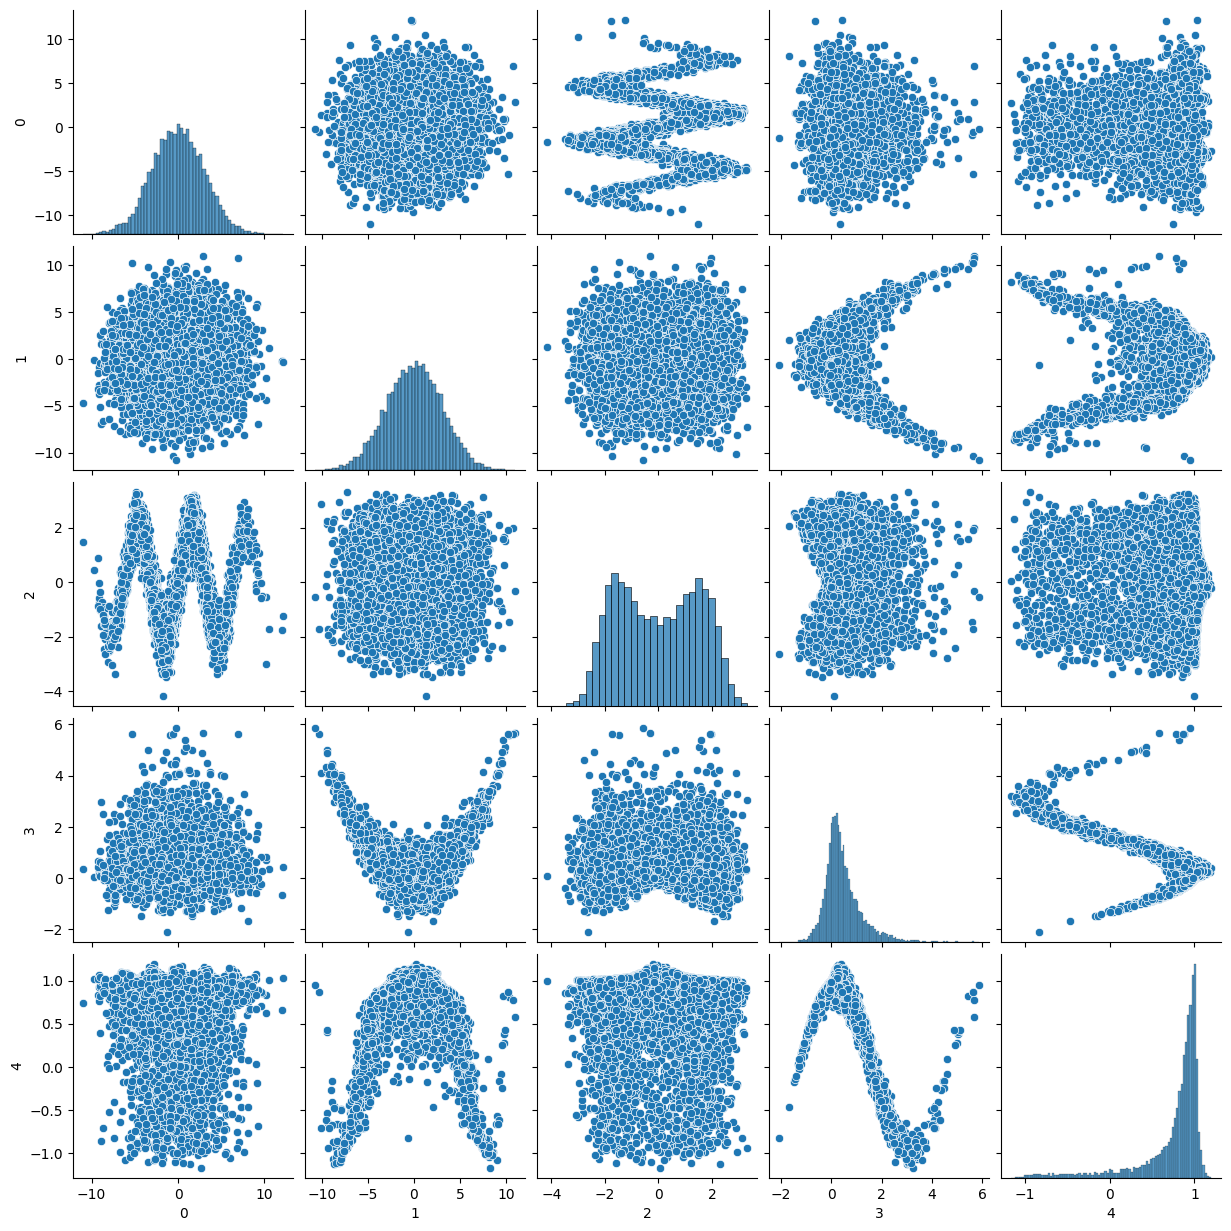

In [8]:
sns.pairplot(pd.DataFrame(samples))